In [1]:
!pip install tensorflow
!pip install matplotlib
!pip install scikit-learn
!pip install scipy
!pip install efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.21.3 r

In [2]:
import os
import shutil
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

2025-12-13 19:39:19.912616: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765654760.321053      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765654760.447054      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ GPU Detected: {len(gpus)} device(s)")
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    else:
        print("⚠️ No GPU detected. Training will be slow.")
except RuntimeError as e:
    print(f"GPU Error: {e}")


✅ GPU Detected: 2 device(s)


In [4]:
data_dir = "/kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer"
output_dir = "/kaggle/working/processed-dataset"  
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoints_path, exist_ok=True)
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 50            

PATIENCE = 10
DECAY = 1e-4


In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = '/kaggle/input/multi-cancer/Multi Cancer/Multi Cancer/Cervical Cancer'

def load_data(root_dir):
    file_paths = []
    labels = []
    
    if not os.path.exists(root_dir):
        print(f"ERROR: Directory not found: {root_dir}")
        return pd.DataFrame()

    classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    
    for class_name in classes:
        class_dir = os.path.join(root_dir, class_name)
        for root, dirs, files in os.walk(class_dir):
            for file in files:
                if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                    file_paths.append(os.path.join(root, file))
                    labels.append(class_name)

    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    return df


data = load_data(DATA_DIR)

if data.empty:
    raise ValueError("No images found! Check your path.")

# Split: 70% Train, 15% Val, 15% Test
train_dataframe, temp_dataframe = train_test_split(
    data, test_size=0.30, stratify=data['label'], random_state=42
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe, test_size=0.50, stratify=temp_dataframe['label'], random_state=42
)

print(f"Data Loaded: {len(train_dataframe)} training images.")

Data Loaded: 17500 training images.


In [6]:

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
print("\n--- creating generators ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_dataframe,
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=validation_dataframe,
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_dataframe,
    x_col='file_path',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

NUM_CLASSES = len(train_generator.class_indices)



--- creating generators ---
Found 17500 validated image filenames belonging to 5 classes.
Found 3750 validated image filenames belonging to 5 classes.
Found 3750 validated image filenames belonging to 5 classes.


In [7]:
print("\n--- Building ResNet50 ---")

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


--- Building ResNet50 ---


I0000 00:00:1765654847.422247      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765654847.422980      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print("\n--- Starting Training ---")
start_train_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

total_train_time = time.time() - start_train_time
print(f"✅ Training Complete in {total_train_time:.2f} seconds")


--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1765654858.853917      88 service.cc:148] XLA service 0x7996dc002560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765654858.855418      88 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765654858.855437      88 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765654860.371742      88 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/547 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.1953 - loss: 2.9740   

I0000 00:00:1765654865.787810      88 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 374s 659ms/step - accuracy: 0.7378 - loss: 0.7401 - val_accuracy: 0.9581 - val_loss: 0.1381
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 242s 443ms/step - accuracy: 0.9454 - loss: 0.1670 - val_accuracy: 0.9811 - val_loss: 0.0679
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 233s 426ms/step - accuracy: 0.9705 - loss: 0.0907 - val_accuracy: 0.9896 - val_loss: 0.0448
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 238s 436ms/step - accuracy: 0.9786 - loss: 0.0745 - val_accuracy: 0.9939 - val_loss: 0.0309
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 239s 436ms/step - accuracy: 0.9878 - loss: 0.0462 - val_accuracy: 0.9944 - val_loss: 0.0210
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 233s 427ms/step - accuracy: 0.9912 - loss: 0.0350 - val_accuracy: 0.9971 - val_loss: 0.0152
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 231s 423ms/step - accuracy: 0.9943 - loss: 0.0263 - val_accuracy: 0.9960 - val_loss: 0.0142
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 229s 419ms/step - accuracy: 0.9943 - loss: 0.02


--- Model Evaluation ---
118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 379ms/step

=== Classification Report ===
              precision    recall  f1-score   support

  cervix_dyk       1.00      1.00      1.00       750
  cervix_koc       1.00      1.00      1.00       750
  cervix_mep       0.99      1.00      1.00       750
  cervix_pab       1.00      1.00      1.00       750
  cervix_sfi       1.00      1.00      1.00       750

    accuracy                           1.00      3750
   macro avg       1.00      1.00      1.00      3750
weighted avg       1.00      1.00      1.00      3750


=== Class Accuracy ===
cervix_dyk: 99.73%
cervix_koc: 99.73%
cervix_mep: 100.00%
cervix_pab: 100.00%
cervix_sfi: 100.00%


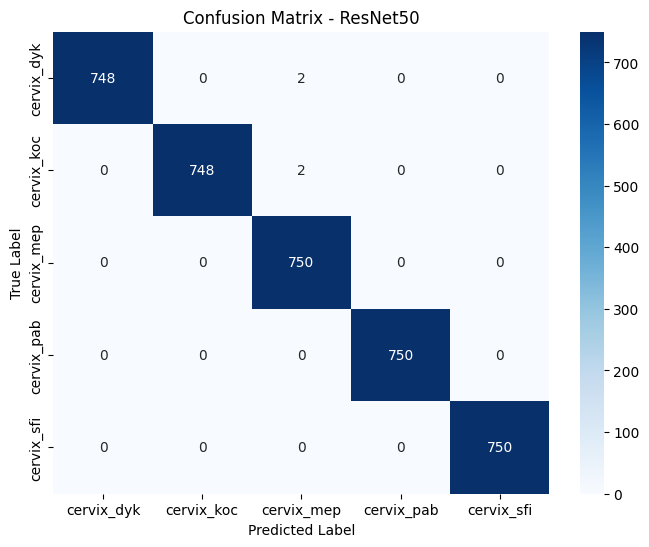


=== ROC Curve & AUC ===


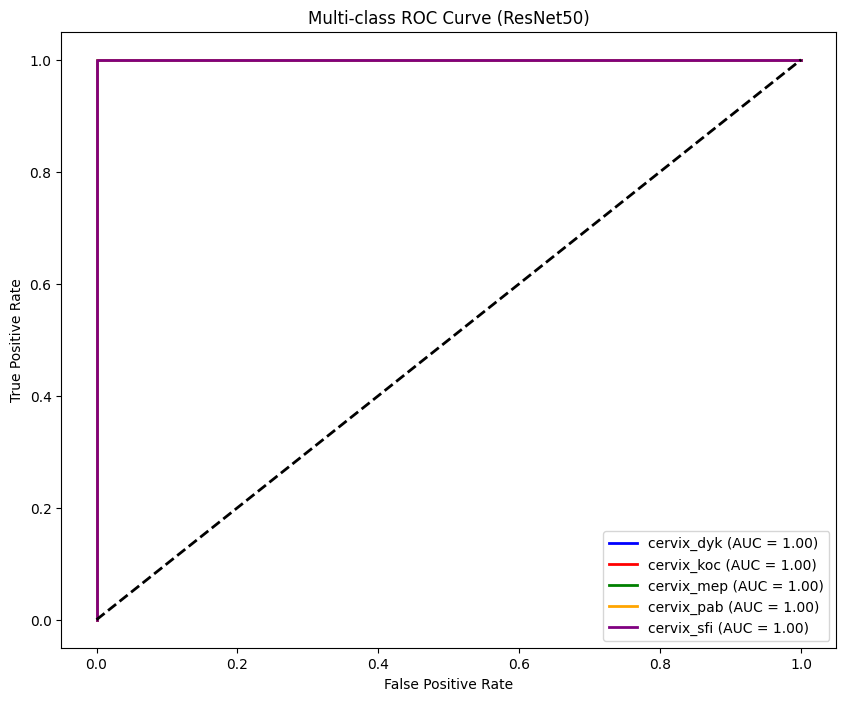


=== Time Metrics ===
Training Time: 11716.68 s
Testing Time:  48.93 s


In [9]:
print("\n--- Model Evaluation ---")
start_test_time = time.time()
y_pred_probs = model.predict(test_generator)
total_test_time = time.time() - start_test_time

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes # This works because shuffle=False

map_labels = {v: k for k, v in train_generator.class_indices.items()}
target_names = [map_labels[i] for i in range(NUM_CLASSES)]

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=target_names))

print("\n=== Class Accuracy ===")
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, name in enumerate(target_names):
    print(f"{name}: {per_class_acc[i]*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - ResNet50')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n=== ROC Curve & AUC ===")
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (ResNet50)')
plt.legend(loc="lower right")
plt.show()

print("\n=== Time Metrics ===")
print(f"Training Time: {total_train_time:.2f} s")
print(f"Testing Time:  {total_test_time:.2f} s")